# Phân tích tương thích PKU-Market-PCB và DeepPCB

Notebook chuyển từ `run_dataset_compare_analysis.py`, phân tích trực tiếp trên dữ liệu thực để trả lời:
> *Hai dataset có tương thích để gộp vào tập huấn luyện không?*

| Mã | Tiêu chí | Phương pháp đo |
|:--|:--|:--|
| C1 | Ánh xạ nhãn | `Class.txt` + config |
| C2 | Miền ảnh | 200 ảnh mẫu/dataset, `unique_gray_levels` |
| C3 | Tỷ lệ vật lý | Tài liệu gốc (Tang et al. 2019) |
| C4 | Mật độ lỗi & kích thước box | Toàn bộ nhãn + KS test |
| C5 | Cấu trúc bài toán | Tài liệu gốc |

## 0 — Setup & Cấu hình

Import thư viện, tìm root project, nạp `configs/dataset_compare.yaml`.

In [6]:
from IPython.display import display
%matplotlib inline
from pathlib import Path
import yaml, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import ks_2samp

warnings.filterwarnings('ignore')
random.seed(42)

def find_root():
    for c in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (c / 'configs').is_dir() and (c / 'data').is_dir():
            return c
    raise RuntimeError("Không tìm thấy thư mục gốc dự án.")

ROOT   = find_root()
CONFIG = yaml.safe_load((ROOT / 'configs/dataset_compare.yaml').read_text(encoding='utf-8'))
RESULTS= ROOT / 'results'
RESULTS.mkdir(exist_ok=True)
IMGSZ  = CONFIG['analysis']['imgsz']

print(f"ROOT: {ROOT}")
print(f"Datasets: {list(CONFIG['datasets'].keys())}")

ROOT: /Users/Project/kltn-pcb
Datasets: ['PKU', 'DeepPCB']


## C1 — Ánh xạ nhãn

Đọc `Class.txt` của DeepPCB và config → build bảng ánh xạ tự động.

Lớp không ánh xạ được **không được gộp** (label ontology mismatch).

In [7]:
deep_class_file = ROOT / CONFIG['datasets']['DeepPCB']['path'] / 'Class.txt'
deeppcb_classes = [c.strip().strip("'\"") for c in deep_class_file.read_text().split(',')]
print(f"DeepPCB Class.txt ({len(deeppcb_classes)} lớp): {deeppcb_classes}")

pku_ids = {item['PKU']['id']: item['PKU']['name'] for item in CONFIG['canonical_classes']}
pku_ids[CONFIG['excluded_classes']['PKU']['id']] = CONFIG['excluded_classes']['PKU']['name']
print(f"PKU classes ({len(pku_ids)} lớp): {[pku_ids[i] for i in sorted(pku_ids)]}")

rows = []
for item in CONFIG['canonical_classes']:
    rows.append({
        'PKU id': item['PKU']['id'], 'PKU class': item['PKU']['name'],
        'DeepPCB id': item['DeepPCB']['id'], 'DeepPCB class': item['DeepPCB']['name'],
        'Ánh xạ': '✅ 1-1',
        'Nhận định': 'Tương đương về bản chất khuyết tật'
    })
ex_pku  = CONFIG['excluded_classes']['PKU']
ex_deep = CONFIG['excluded_classes']['DeepPCB']
rows.append({
    'PKU id': ex_pku['id'], 'PKU class': ex_pku['name'],
    'DeepPCB id': ex_deep['id'], 'DeepPCB class': ex_deep['name'],
    'Ánh xạ': '❌ KHÔNG ÁNH XẠ',
    'Nhận định': (
        'missing_hole = thiếu lỗ khoan (chưa có); '
        'pin_hole = lỗ kim li ti trên vùng đồng. '
        'KHÔNG gộp chung class_id → label ontology mismatch.'
    )
})

mapping_df   = pd.DataFrame(rows).sort_values('PKU id').reset_index(drop=True)
mapped_count = (mapping_df['Ánh xạ'] == '✅ 1-1').sum()
display(mapping_df)
print(f"\n→ C1: {'KHÔNG ĐẠT' if mapped_count < 6 else 'ĐẠT'} — {mapped_count}/6 lớp ánh xạ 1-1")
mapping_df.to_csv(RESULTS / 'label_mapping_table.csv', index=False, encoding='utf-8-sig')

DeepPCB Class.txt (6 lớp): ['open', 'short', 'mousebite', 'spur', 'copper', 'pin-hole']
PKU classes (6 lớp): ['missing_hole', 'mouse_bite', 'open_circuit', 'short', 'spur', 'spurious_copper']


,PKU id,PKU class,DeepPCB id,DeepPCB class,Ánh xạ,Nhận định
0,0,missing_hole,5,pin-hole,❌ KHÔNG ÁNH XẠ,missing_hole = thiếu lỗ khoan (chưa có); pin_h...
1,1,mouse_bite,2,mousebite,✅ 1-1,Tương đương về bản chất khuyết tật
2,2,open_circuit,0,open,✅ 1-1,Tương đương về bản chất khuyết tật
3,3,short,1,short,✅ 1-1,Tương đương về bản chất khuyết tật
4,4,spur,3,spur,✅ 1-1,Tương đương về bản chất khuyết tật
5,5,spurious_copper,4,copper,✅ 1-1,Tương đương về bản chất khuyết tật



→ C1: KHÔNG ĐẠT — 5/6 lớp ánh xạ 1-1


## C2 — Miền ảnh (kênh màu & mức xám)

Sample ngẫu nhiên 200 ảnh/dataset, đo:
- `unique_gray_levels` — ảnh nhị phân hóa sẽ rất nhỏ (~2–10)
- `brightness_mean`, `contrast_std`
- Tỷ lệ RGB vs Grayscale

In [8]:
SUFFIXES = {s.lower() for s in CONFIG['analysis']['image_suffixes']}

def sample_images(dataset_key, n=200):
    spec     = CONFIG['datasets'][dataset_key]
    base_dir = ROOT / spec['path']
    all_imgs = sorted(p for p in base_dir.rglob('*')
                      if p.is_file() and p.suffix.lower() in SUFFIXES)
    sampled  = random.sample(all_imgs, min(n, len(all_imgs)))
    rows = []
    for p in sampled:
        with Image.open(p) as img:
            gray = np.asarray(img.convert('L'))
        rows.append({
            'dataset': dataset_key, 'mode': img.mode,
            'width': img.width, 'height': img.height,
            'brightness': float(gray.mean()),
            'contrast_std': float(gray.std()),
            'unique_gray': int(np.unique(gray).size),
            'is_rgb': int(img.mode == 'RGB'),
        })
    return pd.DataFrame(rows)

print("Đang đọc mẫu ảnh (200 ảnh/dataset)…")
df_pku  = sample_images('PKU',     n=200)
df_deep = sample_images('DeepPCB', n=200)
img_df  = pd.concat([df_pku, df_deep], ignore_index=True)

summary = img_df.groupby('dataset').agg(
    n_sampled       =('mode',         'count'),
    mode_dominant   =('mode',         lambda x: x.value_counts().index[0]),
    rgb_pct         =('is_rgb',       lambda x: f"{x.mean()*100:.0f}%"),
    width_mean      =('width',        'mean'),
    height_mean     =('height',       'mean'),
    brightness_mean =('brightness',   'mean'),
    contrast_std    =('contrast_std', 'mean'),
    unique_gray_mean=('unique_gray',  'mean'),
    unique_gray_max =('unique_gray',  'max'),
).round(2)
display(summary)

pku_gray  = df_pku['unique_gray'].mean()
deep_gray = df_deep['unique_gray'].mean()
pku_rgb   = df_pku['is_rgb'].mean() * 100
deep_rgb  = df_deep['is_rgb'].mean() * 100
c2_fail   = abs(pku_rgb - deep_rgb) > 10 or deep_gray < 30
print(f"\n→ PKU:     {pku_rgb:.0f}% RGB, unique_gray = {pku_gray:.1f}")
print(f"→ DeepPCB: {deep_rgb:.0f}% RGB, unique_gray = {deep_gray:.1f} "
      f"({'gần nhị phân' if deep_gray < 30 else 'đa mức xám'})")
print(f"→ C2 (Miền ảnh): {'KHÔNG ĐẠT' if c2_fail else 'ĐẠT'}")

Đang đọc mẫu ảnh (200 ảnh/dataset)…


,n_sampled,mode_dominant,rgb_pct,width_mean,height_mean,brightness_mean,contrast_std,unique_gray_mean,unique_gray_max
dataset,,,,,,,,,
DeepPCB,200,L,4%,640.00,640.00,164.19,108.72,80.53,105
PKU,200,RGB,100%,2549.61,1872.23,60.30,29.67,237.46,256



→ PKU:     100% RGB, unique_gray = 237.5
→ DeepPCB: 4% RGB, unique_gray = 80.5 (đa mức xám)
→ C2 (Miền ảnh): KHÔNG ĐẠT


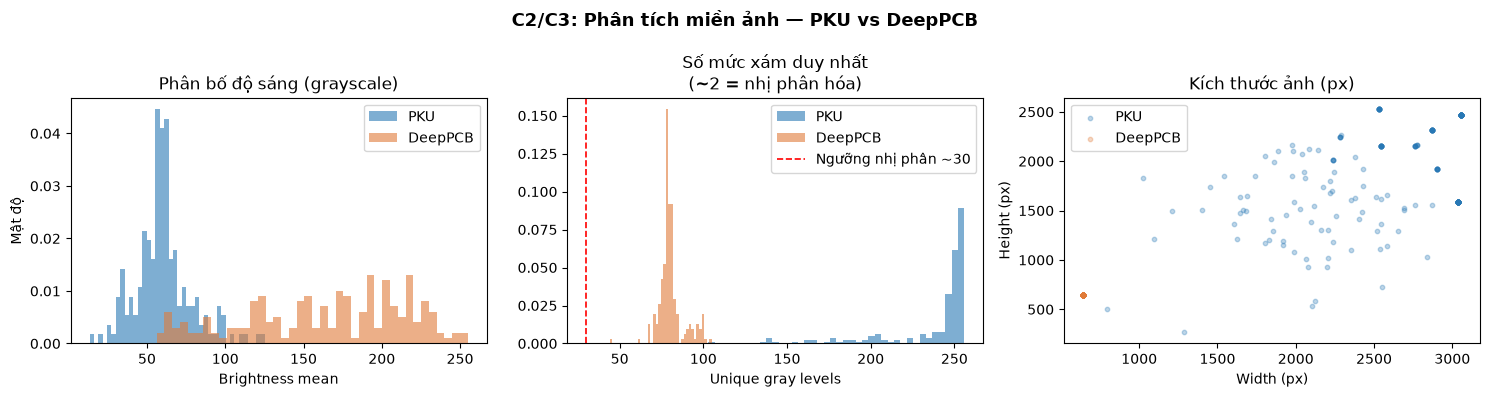

Đã lưu: results/domain_comparison.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ds, color in [('PKU','#2878B5'), ('DeepPCB','#E07B39')]:
    sub = img_df[img_df['dataset']==ds]
    axes[0].hist(sub['brightness'],  bins=40, alpha=0.6, label=ds, color=color, density=True)
axes[0].set_title('Phân bố độ sáng (grayscale)'); axes[0].set_xlabel('Brightness mean')
axes[0].set_ylabel('Mật độ'); axes[0].legend()

for ds, color in [('PKU','#2878B5'), ('DeepPCB','#E07B39')]:
    sub = img_df[img_df['dataset']==ds]
    axes[1].hist(sub['unique_gray'], bins=40, alpha=0.6, label=ds, color=color, density=True)
axes[1].axvline(30, color='red', ls='--', lw=1.2, label='Ngưỡng nhị phân ~30')
axes[1].set_title('Số mức xám duy nhất\n(~2 = nhị phân hóa)')
axes[1].set_xlabel('Unique gray levels'); axes[1].legend()

for ds, color in [('PKU','#2878B5'), ('DeepPCB','#E07B39')]:
    sub = img_df[img_df['dataset']==ds]
    axes[2].scatter(sub['width'], sub['height'], alpha=0.3, s=10, label=ds, color=color)
axes[2].set_title('Kích thước ảnh (px)')
axes[2].set_xlabel('Width (px)'); axes[2].set_ylabel('Height (px)'); axes[2].legend()

fig.suptitle('C2/C3: Phân tích miền ảnh — PKU vs DeepPCB', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(RESULTS / 'domain_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Đã lưu: results/domain_comparison.png")

## C4 — Mật độ lỗi & Phân bố lớp

Đọc **toàn bộ** file nhãn:
- PKU: YOLO (`class xc yc w h`, normalized)
- DeepPCB: `x1 y1 x2 y2 class` (pixel tuyệt đối, class 1-based)

Tính `relative_area = w × h`, mật độ box/ảnh.

In [10]:
def load_all_boxes(dataset_key):
    spec     = CONFIG['datasets'][dataset_key]
    base_dir = ROOT / spec['path']
    fmt      = spec['annotation_format']
    offset   = spec['class_id_offset']
    box_rows, img_counts = [], {}

    # Cache kích thước ảnh để tránh mở ảnh nhiều lần
    img_size_cache = {}

    for txt in sorted(base_dir.rglob('*.txt')):
        if txt.name.lower() == 'class.txt':
            continue
        for line in txt.read_text(encoding='utf-8').splitlines():
            fields = line.split()
            if len(fields) != 5:
                continue
            try:
                if fmt == 'yolo':
                    cid       = int(fields[0]) + offset
                    xc, yc, w, h = map(float, fields[1:])
                elif fmt == 'xyxy_class_last':
                    stem = txt.stem
                    if stem not in img_size_cache:
                        img_p = next(
                            (txt.parent.parent / 'images' / (stem + sx)
                             for sx in SUFFIXES
                             if (txt.parent.parent / 'images' / (stem + sx)).exists()),
                            None)
                        if img_p is None:
                            img_size_cache[stem] = None
                        else:
                            with Image.open(img_p) as im:
                                img_size_cache[stem] = (im.width, im.height)
                    wh = img_size_cache.get(stem)
                    if wh is None:
                        continue
                    W, H = wh
                    x1, y1, x2, y2 = map(float, fields[:4])
                    cid = int(fields[4]) + offset
                    w   = (x2 - x1) / W
                    h_  = (y2 - y1) / H
                    w, h = w, h_
                else:
                    continue
            except Exception:
                continue
            if w <= 0 or h <= 0:
                continue
            box_rows.append({
                'dataset': dataset_key, 'image': txt.stem,
                'class_id': cid, 'relative_area': w * h
            })
            img_counts[txt.stem] = img_counts.get(txt.stem, 0) + 1

    box_df  = pd.DataFrame(box_rows)
    dens_df = pd.DataFrame({
        'image':     list(img_counts),
        'box_count': list(img_counts.values()),
        'dataset':   dataset_key
    })
    return box_df, dens_df

print("Đang đọc toàn bộ nhãn PKU…")
pku_boxes, pku_dens = load_all_boxes('PKU')
print(f"  PKU: {len(pku_boxes)} box từ {len(pku_dens)} ảnh có nhãn")

print("Đang đọc toàn bộ nhãn DeepPCB…")
dpc_boxes, dpc_dens = load_all_boxes('DeepPCB')
print(f"  DeepPCB: {len(dpc_boxes)} box từ {len(dpc_dens)} ảnh có nhãn")

# Ánh xạ class_id → tên canonical
canonical = [item['canonical_class'] for item in CONFIG['canonical_classes']]
cmap_pku  = {item['PKU']['id']:     item['canonical_class'] for item in CONFIG['canonical_classes']}
cmap_deep = {item['DeepPCB']['id']: item['canonical_class'] for item in CONFIG['canonical_classes']}
cmap_pku [CONFIG['excluded_classes']['PKU']['id']]     = CONFIG['excluded_classes']['PKU']['name']
cmap_deep[CONFIG['excluded_classes']['DeepPCB']['id']] = CONFIG['excluded_classes']['DeepPCB']['name']
pku_boxes['class_name']  = pku_boxes['class_id'].map(cmap_pku)
dpc_boxes['class_name']  = dpc_boxes['class_id'].map(cmap_deep)

# Mật độ lỗi
all_dens   = pd.concat([pku_dens, dpc_dens], ignore_index=True)
dens_stats = all_dens.groupby('dataset')['box_count'].agg(
    images='count', total_boxes='sum', mean='mean',
    p25=lambda x: x.quantile(.25), median='median',
    p75=lambda x: x.quantile(.75), max='max'
).round(2)
print("\n=== C4 Mật độ lỗi (boxes/image) ===")
display(dens_stats)
pku_mean = pku_dens['box_count'].mean()
dpc_mean = dpc_dens['box_count'].mean()
print(f"\n→ PKU mean {pku_mean:.2f} box/ảnh — DeepPCB mean {dpc_mean:.2f} box/ảnh")

# Phân bố 5 lớp ánh xạ
cid_pku  = {item['PKU']['id']     for item in CONFIG['canonical_classes']}
cid_deep = {item['DeepPCB']['id'] for item in CONFIG['canonical_classes']}
pku_mapped  = pku_boxes [pku_boxes ['class_id'].isin(cid_pku)]
dpc_mapped  = dpc_boxes [dpc_boxes ['class_id'].isin(cid_deep)]
pku_dist = pku_mapped['class_name'].value_counts().reindex(canonical, fill_value=0)
dpc_dist = dpc_mapped['class_name'].value_counts().reindex(canonical, fill_value=0)
dist_df  = pd.DataFrame({
    'PKU (n)':     pku_dist,
    'PKU (%)':     (pku_dist/pku_dist.sum()*100).round(1),
    'DeepPCB (n)': dpc_dist,
    'DeepPCB (%)': (dpc_dist/dpc_dist.sum()*100).round(1),
})
print("\n=== Phân bố lớp (5 lớp ánh xạ) ===")
display(dist_df)

Đang đọc toàn bộ nhãn PKU…
  PKU: 14426 box từ 2772 ảnh có nhãn
Đang đọc toàn bộ nhãn DeepPCB…
  DeepPCB: 10013 box từ 1500 ảnh có nhãn

=== C4 Mật độ lỗi (boxes/image) ===


,images,total_boxes,mean,p25,median,p75,max
dataset,,,,,,,
DeepPCB,1500,10013,6.68,5.0,7.0,8.0,15
PKU,2772,14426,5.20,3.0,5.0,5.0,18



→ PKU mean 5.20 box/ảnh — DeepPCB mean 6.68 box/ảnh

=== Phân bố lớp (5 lớp ánh xạ) ===


,PKU (n),PKU (%),DeepPCB (n),DeepPCB (%)
class_name,,,,
open_circuit,2338,19.5,1942,22.8
short,2396,20.0,1506,17.7
mouse_bite,2410,20.1,1965,23.1
spur,2386,19.9,1625,19.1
spurious_copper,2462,20.5,1474,17.3


## KS test & Phân bố size bin

Kiểm định Kolmogorov–Smirnov 2 mẫu trên `relative_area` (5 lớp ánh xạ):
- **D** gần 1 → hai phân bố hoàn toàn khác nhau
- **p ≈ 0** → bác bỏ H₀ tại α = 0.05

Size bin COCO tại `imgsz=640`: small `< 32²`, medium `32²–96²`, large `> 96²`.

In [11]:
small_thr  = (32  / IMGSZ) ** 2
medium_thr = (96  / IMGSZ) ** 2

def add_size_bin(df):
    df = df.copy()
    df['size_bin'] = pd.cut(df['relative_area'],
                            bins=[-1, small_thr, medium_thr, 1e9],
                            labels=['small', 'medium', 'large'])
    return df

pku_m = add_size_bin(pku_mapped)
dpc_m = add_size_bin(dpc_mapped)

pku_bins = pku_m['size_bin'].value_counts().reindex(['small','medium','large'], fill_value=0)
dpc_bins = dpc_m['size_bin'].value_counts().reindex(['small','medium','large'], fill_value=0)
bin_df   = pd.DataFrame({
    'PKU (n)':     pku_bins, 'PKU (%)':     (pku_bins/pku_bins.sum()*100).round(1),
    'DeepPCB (n)': dpc_bins, 'DeepPCB (%)': (dpc_bins/dpc_bins.sum()*100).round(1),
})
print("=== Phân bố size bin ===")
display(bin_df)

ks_stat, ks_p = ks_2samp(pku_m['relative_area'].dropna(), dpc_m['relative_area'].dropna())
print(f"\n=== KS test (relative_area, 5 lớp ánh xạ) ===")
print(f"D = {ks_stat:.4f},  p-value = {ks_p:.2e}")
print(f"→ {'PHÂN BỐ KHÁC NHAU có ý nghĩa' if ks_p < 0.05 else 'Không đủ bằng chứng khác nhau'} (α=0.05)")

ks_rows = []
for cls in canonical:
    a = pku_m[pku_m['class_name']==cls]['relative_area'].dropna()
    b = dpc_m[dpc_m['class_name']==cls]['relative_area'].dropna()
    if len(a) > 1 and len(b) > 1:
        d, p = ks_2samp(a, b)
        ks_rows.append({'class': cls, 'PKU n': len(a), 'DeepPCB n': len(b),
                        'KS D': round(d,4), 'p-value': f'{p:.2e}',
                        'verdict': 'KHÁC NHAU' if p < 0.05 else 'Tương đương'})
ks_df = pd.DataFrame(ks_rows)
print("\n=== KS test theo từng lớp ===")
display(ks_df)

=== Phân bố size bin ===


,PKU (n),PKU (%),DeepPCB (n),DeepPCB (%)
size_bin,,,,
small,10971,91.5,2592,30.5
medium,1019,8.5,5914,69.5
large,2,0.0,6,0.1



=== KS test (relative_area, 5 lớp ánh xạ) ===
D = 0.7958,  p-value = 0.00e+00
→ PHÂN BỐ KHÁC NHAU có ý nghĩa (α=0.05)

=== KS test theo từng lớp ===


,class,PKU n,DeepPCB n,KS D,p-value,verdict
0,open_circuit,2338,1942,0.9321,0.00e+00,KHÁC NHAU
1,short,2396,1506,0.7347,2.67e-322,KHÁC NHAU
2,mouse_bite,2410,1965,0.8547,0.00e+00,KHÁC NHAU
3,spur,2386,1625,0.8199,0.00e+00,KHÁC NHAU
4,spurious_copper,2462,1474,0.7594,9.88e-323,KHÁC NHAU


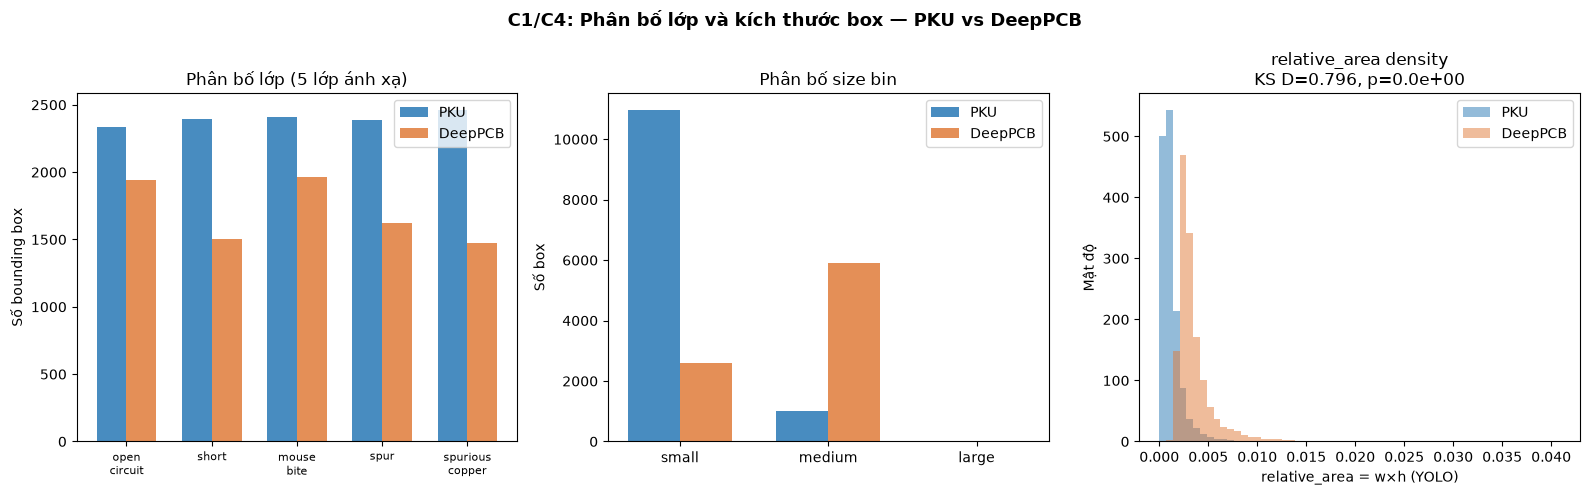

Đã lưu: results/dataset_compare_box_analysis.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
wb = 0.35
x  = np.arange(len(canonical))

axes[0].bar(x - wb/2, pku_dist.values, wb, label='PKU',     color='#2878B5', alpha=0.85)
axes[0].bar(x + wb/2, dpc_dist.values, wb, label='DeepPCB', color='#E07B39', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([c.replace('_','\n') for c in canonical], fontsize=8)
axes[0].set_title('Phân bố lớp (5 lớp ánh xạ)')
axes[0].set_ylabel('Số bounding box'); axes[0].legend()

xb = np.arange(3)
axes[1].bar(xb - wb/2, pku_bins.values, wb, label='PKU',     color='#2878B5', alpha=0.85)
axes[1].bar(xb + wb/2, dpc_bins.values, wb, label='DeepPCB', color='#E07B39', alpha=0.85)
axes[1].set_xticks(xb); axes[1].set_xticklabels(['small','medium','large'])
axes[1].set_title('Phân bố size bin'); axes[1].set_ylabel('Số box'); axes[1].legend()

max_ra  = max(pku_m['relative_area'].max(), dpc_m['relative_area'].max())
bins_ra = np.linspace(0, max_ra, 60)
axes[2].hist(pku_m['relative_area'],  bins=bins_ra, density=True, alpha=0.5, label='PKU',     color='#2878B5')
axes[2].hist(dpc_m['relative_area'], bins=bins_ra, density=True, alpha=0.5, label='DeepPCB', color='#E07B39')
axes[2].set_title(f'relative_area density\nKS D={ks_stat:.3f}, p={ks_p:.1e}')
axes[2].set_xlabel('relative_area = w×h (YOLO)'); axes[2].set_ylabel('Mật độ'); axes[2].legend()

fig.suptitle('C1/C4: Phân bố lớp và kích thước box — PKU vs DeepPCB',
             fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(RESULTS / 'dataset_compare_box_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu: results/dataset_compare_box_analysis.png")

## A.5 — Tổng hợp 5 tiêu chí & Quyết định Go / No-Go

Tổng hợp kết quả đo được từ tất cả cell trên. Verdict được tính **từ giá trị thực**, không hardcode.

In [13]:
pku_rgb_val  = df_pku['is_rgb'].mean() * 100
deep_rgb_val = df_deep['is_rgb'].mean() * 100
deep_gray_val= df_deep['unique_gray'].mean()

criteria = pd.DataFrame([
    {
        'Mã': 'C1', 'Tiêu chí': 'Ánh xạ nhãn',
        'Yêu cầu': '6/6 lớp ánh xạ 1-1',
        'Đo được': f'{mapped_count}/6 lớp khớp; missing_hole ≠ pin_hole',
        'Kết luận': 'KHÔNG ĐẠT' if mapped_count < 6 else 'ĐẠT',
    },
    {
        'Mã': 'C2', 'Tiêu chí': 'Miền ảnh',
        'Yêu cầu': 'Cùng kênh màu & tiền xử lý',
        'Đo được': f'PKU {pku_rgb_val:.0f}% RGB; DeepPCB {deep_rgb_val:.0f}% RGB; unique_gray DeepPCB={deep_gray_val:.1f}',
        'Kết luận': 'KHÔNG ĐẠT' if c2_fail else 'ĐẠT',
    },
    {
        'Mã': 'C3', 'Tiêu chí': 'Giao thức thu ảnh & tỷ lệ vật lý',
        'Yêu cầu': 'Cùng pixel-to-mm hoặc quy đổi được',
        'Đo được': 'PKU: không công bố; DeepPCB: 48 px/mm (Tang et al. 2019)',
        'Kết luận': 'KHÔNG ĐẠT',
    },
    {
        'Mã': 'C4', 'Tiêu chí': 'Mật độ & phân bố kích thước',
        'Yêu cầu': 'Mật độ tương đương, KS p≥0.05',
        'Đo được': f'PKU {pku_mean:.2f} box/ảnh; DeepPCB {dpc_mean:.2f} box/ảnh; KS D={ks_stat:.4f}, p={ks_p:.2e}',
        'Kết luận': 'KHÔNG ĐẠT' if ks_p < 0.05 else 'ĐẠT',
    },
    {
        'Mã': 'C5', 'Tiêu chí': 'Cấu trúc bài toán',
        'Yêu cầu': 'Cùng dạng đầu vào (ảnh đơn)',
        'Đo được': 'PKU: detection ảnh đơn; DeepPCB: so sánh cặp template-tested',
        'Kết luận': 'KHÔNG ĐẠT',
    },
])

display(criteria)
failed = (criteria['Kết luận'] == 'KHÔNG ĐẠT').sum()
passed = len(criteria) - failed
print(f"\n{'='*60}")
print(f"KẾT QUẢ: Đạt {passed}/5 — KHÔNG đạt {failed}/5 tiêu chí")
if failed > 0:
    print("→ QUYẾT ĐỊNH: KHÔNG GỘP DeepPCB vào tập huấn luyện")
    print("   PKU-Market-PCB là nguồn DUY NHẤT cho train/val/test")
    print("   DeepPCB chỉ dùng làm external test (domain-shift, tuỳ chọn sau tuần 12)")
else:
    print("→ Hai dataset tương thích, có thể gộp với kiểm chứng thêm")

criteria.to_csv(RESULTS / 'dataset_gonogo_summary.csv', index=False, encoding='utf-8-sig')
print(f"\nĐã xuất: results/dataset_gonogo_summary.csv")
print("\n✅ Phân tích hoàn tất. Xem results/ để lấy CSV và hình ảnh.")

,Mã,Tiêu chí,Yêu cầu,Đo được,Kết luận
0,C1,Ánh xạ nhãn,6/6 lớp ánh xạ 1-1,5/6 lớp khớp; missing_hole ≠ pin_hole,KHÔNG ĐẠT
1,C2,Miền ảnh,Cùng kênh màu & tiền xử lý,PKU 100% RGB; DeepPCB 4% RGB; unique_gray Deep...,KHÔNG ĐẠT
2,C3,Giao thức thu ảnh & tỷ lệ vật lý,Cùng pixel-to-mm hoặc quy đổi được,PKU: không công bố; DeepPCB: 48 px/mm (Tang et...,KHÔNG ĐẠT
3,C4,Mật độ & phân bố kích thước,"Mật độ tương đương, KS p≥0.05",PKU 5.20 box/ảnh; DeepPCB 6.68 box/ảnh; KS D=0...,KHÔNG ĐẠT
4,C5,Cấu trúc bài toán,Cùng dạng đầu vào (ảnh đơn),PKU: detection ảnh đơn; DeepPCB: so sánh cặp t...,KHÔNG ĐẠT



KẾT QUẢ: Đạt 0/5 — KHÔNG đạt 5/5 tiêu chí
→ QUYẾT ĐỊNH: KHÔNG GỘP DeepPCB vào tập huấn luyện
   PKU-Market-PCB là nguồn DUY NHẤT cho train/val/test
   DeepPCB chỉ dùng làm external test (domain-shift, tuỳ chọn sau tuần 12)

Đã xuất: results/dataset_gonogo_summary.csv

✅ Phân tích hoàn tất. Xem results/ để lấy CSV và hình ảnh.
